In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, Flatten, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dir_name = #replace with file path
df = pd.read_csv(f"{dir_name}#Replace with file name")
df.head()

,Year,Month,Residential Monthly Average,Commercial Monthly Average,Government Monthly Average,RAINFALL,TMAX,TMIN,TMEAN,WIND_SPEED,WIND_DIRECTION,RH
0,2010,1,4940168.0,702499.0,156935.0,5.080645,30.564516,23.909677,27.258065,2.354839,213.225806,84.258065
1,2010,2,3996492.0,601294.0,137278.0,0.571429,32.521429,23.550000,28.053571,2.607143,176.071429,78.071429
2,2010,3,4423759.0,654733.0,145150.0,1.706452,33.493548,24.390323,28.954839,2.741935,159.354839,78.096774
3,2010,4,4605206.0,672214.0,141869.0,4.133333,32.516667,24.800000,28.680000,2.100000,245.666667,82.166667
4,2010,5,4475865.0,642270.0,137791.0,1.848387,32.822581,25.522581,29.193548,1.903226,164.516129,83.064516


In [4]:
# Load the data
data = df['Commercial Monthly Average'].values.reshape(-1, 1)

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [5]:
# Function to create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Define sequence length
sequence_length = 12  # 12 months for seasonal pattern

# Create sequences
X, y = create_sequences(scaled_data, sequence_length)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [6]:
# Build the CNN-LSTM model
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))
cnn_layer = Conv1D(filters=64, kernel_size=2, activation='relu')(input_layer)
cnn_layer = MaxPooling1D(pool_size=2)(cnn_layer)

# No Flatten layer here; instead, pass directly to LSTM
lstm_layer = LSTM(50, activation='relu', return_sequences=False)(cnn_layer)
dropout_layer = Dropout(0.2)(lstm_layer)
dense_layer1 = Dense(25, activation='relu')(dropout_layer)
output_layer = Dense(1)(dense_layer1)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer='adam', loss='mse')

# Display the model summary to verify
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 12, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 11, 64)              │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 50)                  │          23,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,493 (95.68 KB)

 Trainable params: 24,493 (95.68 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Early stopping for preventing overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Stop training after 10 epochs with no improvement
    restore_best_weights=True  # Restore the best model weights after stopping
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 0.3662 - val_loss: 0.4620
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2731 - val_loss: 0.3505
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2024 - val_loss: 0.2378
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1337 - val_loss: 0.1256
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0629 - val_loss: 0.0384
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0175 - val_loss: 0.0175
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0223 - val_loss: 0.0339
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0321 - val_loss: 0.0178
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0258 - val_loss: 0.0173
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0179 - val_loss: 0.0265
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0153 - val_loss: 0.0285
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0133 - val_l

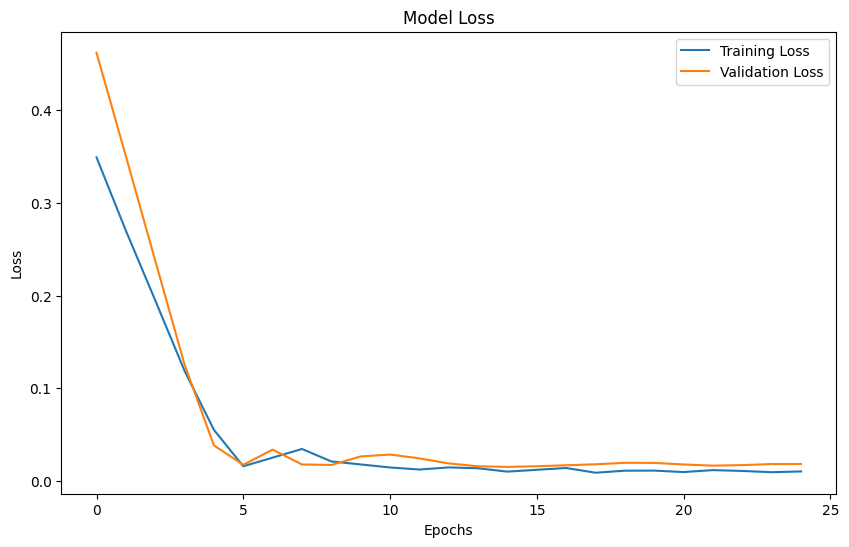

In [8]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
# Generate predictions on the test set
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to original scale (if normalized)
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)

# Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test_rescaled - y_pred_rescaled) / y_test_rescaled)) * 100

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))

print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
MAE: 146503.59
MAPE: 8.98%
RMSE: 162350.37


In [10]:
# Create a DataFrame for test predictions
test_predictions_df = pd.DataFrame({
    'Year': df['Year'][-len(y_test_rescaled):].values,  # Extract the corresponding years
    'Month': df['Month'][-len(y_test_rescaled):].values,  # Extract the corresponding months
    'Actual': y_test_rescaled.flatten(),  # Actual values
    'Prediction': y_pred_rescaled.flatten()  # Predicted values
})

# Combine Year and Month into a Date column
test_predictions_df['Date'] = pd.to_datetime(test_predictions_df[['Year', 'Month']].assign(Day=1))

# Drop the Year and Month columns if you only need the Date
test_predictions_df = test_predictions_df[['Date', 'Actual', 'Prediction']]

# Save the predictions DataFrame to a CSV file
output_file = '/content/drive/MyDrive/THESIS/Codes/[Base] CNN-LSTM/Commercial_test_predictions.csv'
test_predictions_df.to_csv(output_file, index=False)

print(f"Test predictions saved to {output_file}")

Test predictions saved to /content/drive/MyDrive/THESIS/Codes/[Base] CNN-LSTM/Commercial_test_predictions.csv
